# Individual planning 


# 1. Data Description


## Data Set Overview
A) player.csv
- Contains general information about each player
- Each row represents a single player
- Number of observations: 196 rows 
- Number of variables: 7 columns 
1) Quantitative variables:
- played_hours: Total hours played across all sessions (hours)
- Age: Age of the player (years)
2) Qualitative variables:
- experience: Self-reported gaming experience level (e.g., beginner, intermediate, expert)
- gender: Gender identity of the player
- subscribe: Whether the player subscribed to the newsletter (TRUE/FALSE)
- name: Player’s chosen username
- hashedEmail: Anonymized email identifier (not used for analysis


B) sessions.csv
- Contains logs of individual play sessions
- Each row represents a single player
- Number of observations: 1535 rows 
- Number of variables: 5 columns 
1) Quantitative variables
- original_start_time: Numeric representation of session start time 
- original_end_time: Numeric representation of session end time 
2) Qualitative variables
- hashedEmail: Anonymized player identifier used to link sessions to players
- start_time: Human-readable session start time (character format)
- end_time: Human-readable session end time (character format)


In [18]:
#summary table of key descriptive statistics for players.csv data

summary_stats_players <- players |>
  summarise(across(
    c(Age, played_hours),
    list(
      Mean = ~mean(.x, na.rm = TRUE),
      SD = ~sd(.x, na.rm = TRUE),
      Min = ~min(.x, na.rm = TRUE),
      Max = ~max(.x, na.rm = TRUE))))
round (summary_stats_players, 2)



Age_Mean,Age_SD,Age_Min,Age_Max,played_hours_Mean,played_hours_SD,played_hours_Min,played_hours_Max
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
21.14,7.39,9,58,5.85,28.36,0,223.1


On average, players are 21.14 years old (SD = 7.39), with a range from 9 to 58 years. The average playtime is 5.85 hours (SD = 28.36), suggesting large variation in player engagement.

### Potential Data Issues

1) Missing values: Some players may not report age or gender, or have incomplete session records.
2) Outliers: A few players might have extremely high total playtime, vice versas.
3) Generalization issues: Newsletter subscribers may be a minority, requiring resampling or generalization.
4) Unobservable factors: Motivation or personality type may affect subscription but are not recorded.

# 2. Questions
I will study Question 1: which player characteristics and behaviours predict subscribing to a game-related newsletter?

Specific question: Can age, gender, total playtime, and player type predict whether a player subscribes to the newsletter in the players.csv dataset?

To answer whether age, gender, total playtime, and player type predict newsletter subscription, I’ll use the players.csv dataset. The response variable is subscribe, and the predictors are Age, gender, played_hours, and experience. I’ll clean the data, convert categorical variables to factors, and use a classification model to identify which traits are most associated with subscribing. This will help the research team target communication more effectively.
To explore the data, I selected bar plots, histograms, and scatter plots because they effectively reveal patterns without requiring complex modeling.



 # 3. Exploratory Data Analysis and Visualization

In [22]:
#load data
library(tidyverse)
library(ggplot2) 

players <- read_csv("data/players.csv")
sessions <- read_csv("data/sessions.csv")

players
sessions

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17
Regular,TRUE,8e594b8953193b26f498db95a508b03c6fe1c24bb5251d392c18a0da9a722807,0.0,Luna,Female,19
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21
Amateur,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,15/04/2024 07:12,15/04/2024 07:21,1.71317e+12,1.71317e+12
ad6390295640af1ed0e45ffc58a53b2d9074b0eea694b16210addd44d7c81f83,21/09/2024 02:13,21/09/2024 02:30,1.72688e+12,1.72689e+12
96e190b0bf3923cd8d349eee467c09d1130af143335779251492eb4c2c058a5f,21/06/2024 02:31,21/06/2024 02:49,1.71894e+12,1.71894e+12


In [23]:
summary_stats_players <- players |>
  summarise(across(
    c(Age, played_hours),
    list(
      Mean = ~mean(.x, na.rm = TRUE),
      SD = ~sd(.x, na.rm = TRUE),
      Min = ~min(.x, na.rm = TRUE),
      Max = ~max(.x, na.rm = TRUE))))
round (summary_stats_players, 2)

Age_Mean,Age_SD,Age_Min,Age_Max,played_hours_Mean,played_hours_SD,played_hours_Min,played_hours_Max
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
21.14,7.39,9,58,5.85,28.36,0,223.1


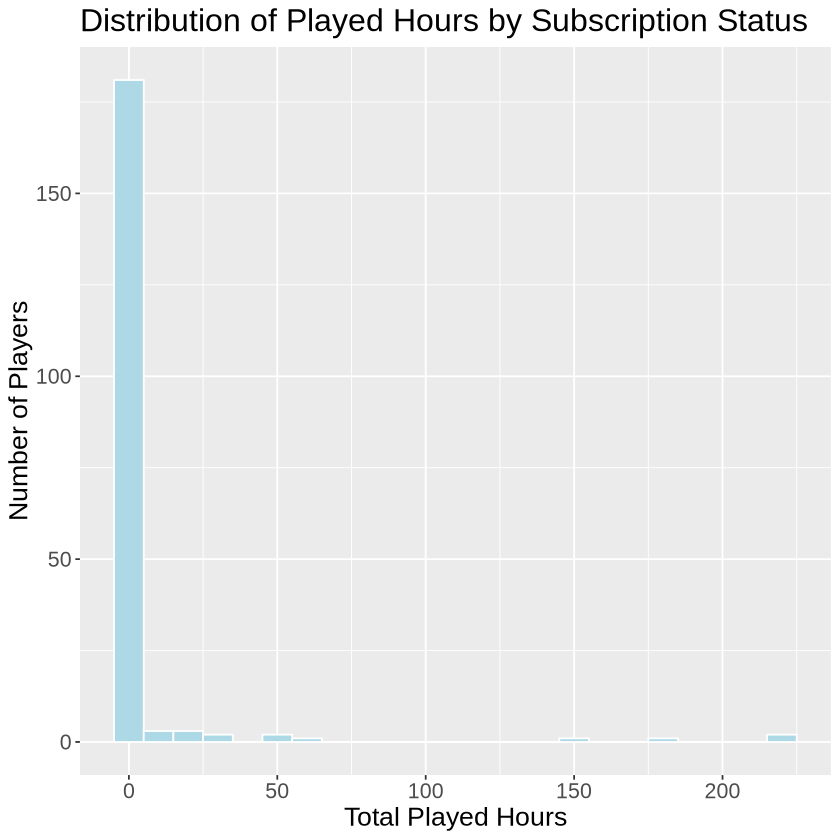

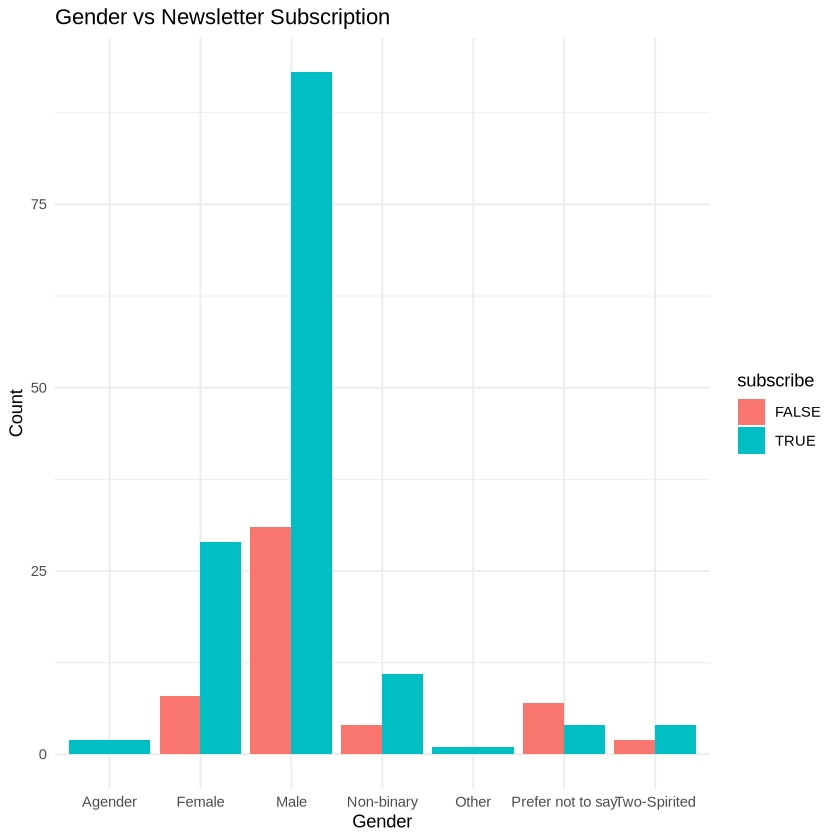

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


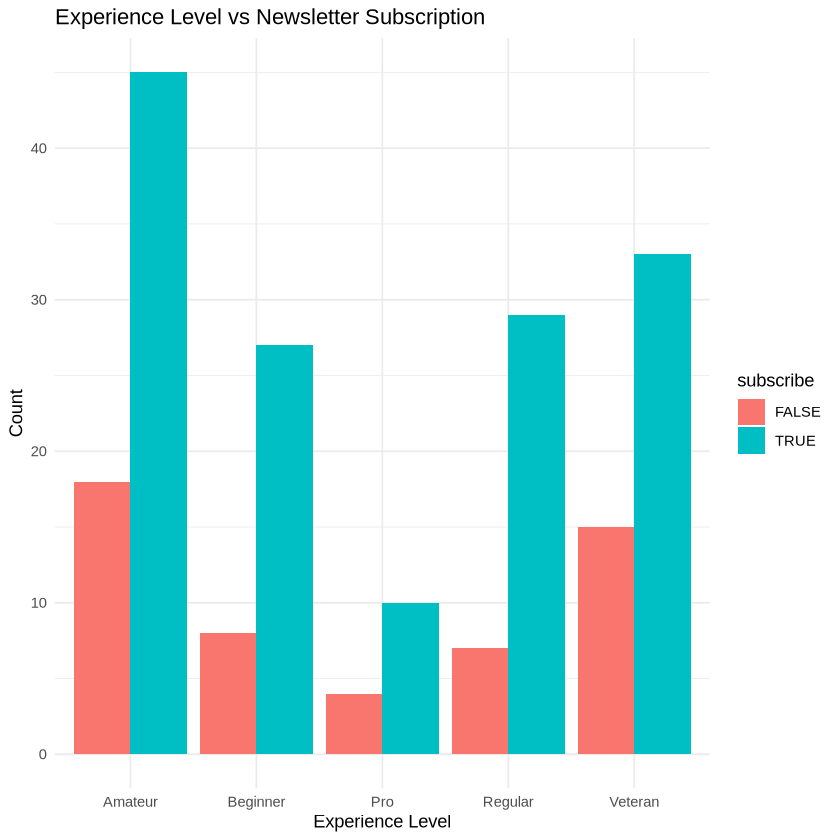

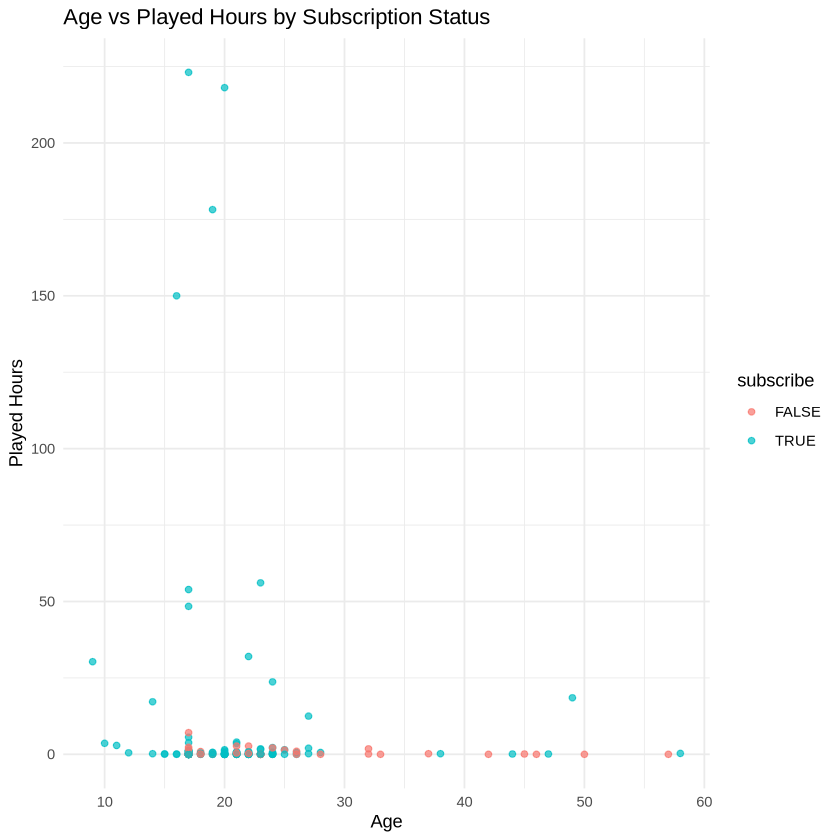

In [26]:
#played hours
played_hours_plot <- players %>%
  ggplot(aes(x = played_hours)) +
  geom_histogram(binwidth = 10, fill = "lightblue", color = "white") +
  xlab("Total Played Hours") +
  ylab("Number of Players") +
  ggtitle("Distribution of Played Hours by Subscription Status") +
  theme(text = element_text(size = 16))

played_hours_plot


#gender distribution by subscription
gender_dis_plot <- players |>
  ggplot(aes(x = gender, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Gender vs Newsletter Subscription",
       x = "Gender",
       y = "Count") +
  theme_minimal()
gender_dis_plot

#subscription vs experience
subs_exp_plot <- ggplot(players, aes(x = experience, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Experience Level vs Newsletter Subscription",
       x = "Experience Level",
       y = "Count") +
  theme_minimal()
subs_exp_plot

#relationship between age and played hours
age_ph_plot <- ggplot(players, aes(x = Age, y = played_hours, color = subscribe)) +
  geom_point(alpha = 0.7) +
  labs(title = "Age vs Played Hours by Subscription Status",
       x = "Age",
       y = "Played Hours") +
  theme_minimal()
age_ph_plot

- Bar plots are ideal for comparing categorical variables like gender and experience across subscription status. They show how many players in each group subscribed or didn’t, helping identify potential associations.
- Histograms help visualize the distribution of played_hours, a continuous variable. This shows whether subscribers tend to play more or less than non-subscribers.
- Scatter plot allows me to examine the relationship between two numeric variables (Age and played_hours) while coloring by subscribe. This helps detect trends or clusters that might indicate predictive relationships.
These plots provide a strong foundation for understanding the data structure


# 4. Methods and Plan

To explore whether age, gender, total playtime, and player type predict newsletter subscription, I propose using K-Nearest Neighbors (KNN) classification. This method is appropriate because the outcome is binary and KNN classifies observations based on the majority label among their nearest neighbors. It’s a non-parametric method that doesn’t assume a specific relationship between predictors and the outcome, making it flexible for pattern detection. KNN assumes that similar data points are close together in feature space, so numeric variables like age and played hours must be scaled. Its limitations include sensitivity to irrelevant features, outliers, and the choice of k, which affects performance. I will evaluate the model using accuracy and compare different values of k using cross-validation. The data will be cleaned, encoded, and split into 70% training and 30% testing after preprocessing. I will use 5-fold cross-validation on the training set to tune k and assess model stability.